# 03B - Bivariate Analysis

Compare financial features between healthy and failed companies.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(8,4)
df=pd.read_csv("../data/datasets/american_bankruptcy.csv")
num=df.select_dtypes(include='number').columns


## Target Overview

In [2]:
display(df['status_label'].value_counts())
(df['status_label'].value_counts(normalize=True)*100).round(2)

status_label
alive     73462
failed     5220
Name: count, dtype: int64

status_label
alive     93.37
failed     6.63
Name: proportion, dtype: float64

## Group Statistics

In [3]:
group_stats=df.groupby('status_label')[list(num)].agg(['mean','median','std'])
display(group_stats)

year                            X1            \
                     mean  median       std        mean    median   
status_label                                                        
alive         2007.633892  2007.0  5.782439  914.542615  102.9175   
failed        2005.710920  2005.0  4.805925  399.339353   75.8715   

                                    X2                                 X3  \
                      std         mean    median          std        mean   
status_label                                                                
alive         4052.047889  1646.982563  103.5340  9210.587641  123.746364   
failed        1147.837282   856.340997  106.6385  2767.913221   85.880919   

              ...          X15          X16                          \
              ...          std         mean    median           std   
status_label  ...                                                     
alive         ...  6570.280016  2447.871581  187.0700  12326.442146   
failed        ...  1849.943497  1183.957172  180.8345   3567.878694   

                      X17                                X18            \
                     mean   median          std         mean    median   
status_label                                                             
alive         1809.571974  80.7405  8257.442726  2054.187022  170.2905   
failed        1266.816748  97.0350  4221.179588  1045.388596  155.7270   

                            
                       std  
status_label                
alive         10744.450269  
failed         3297.762745  

[2 rows x 57 columns]

## Mean Comparison

status_label,alive,failed
year,2007.633892,2005.710920
X1,914.542615,399.339353
X2,1646.982563,856.340997
X3,123.746364,85.880919
X4,393.684586,138.568576
X5,208.560102,103.735398
X6,141.994726,-48.112333
X7,297.794547,132.565307
X8,3596.015157,857.813011
X9,2447.871581,1183.957172


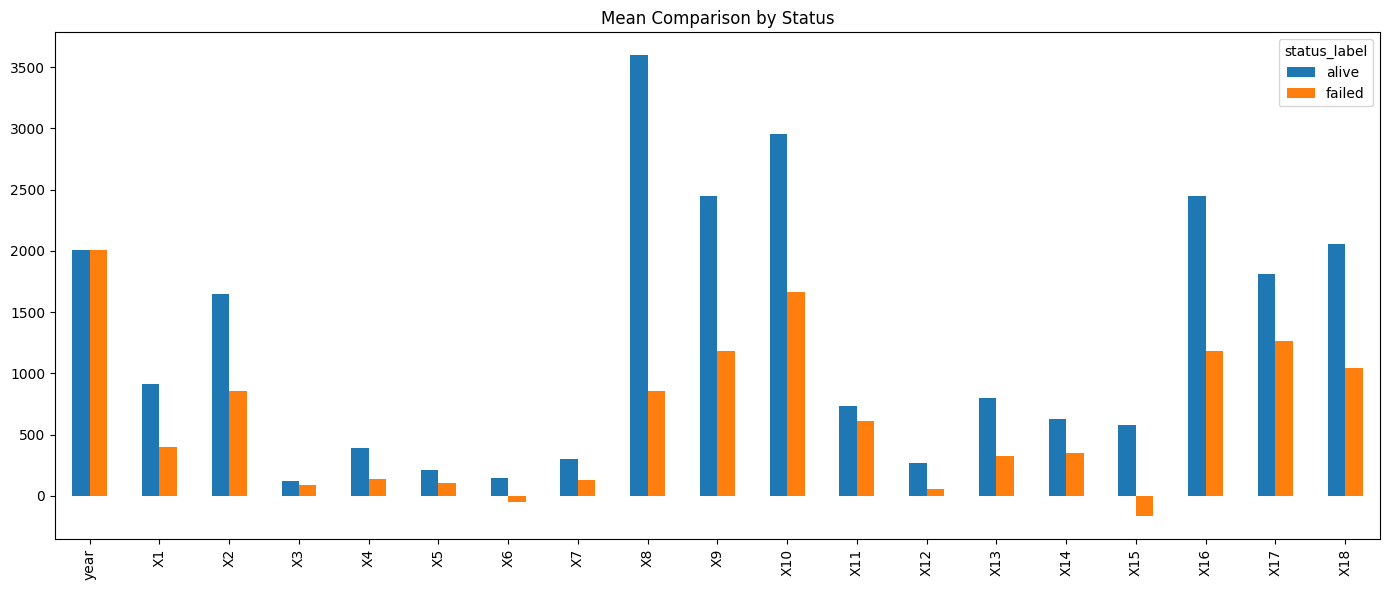

In [4]:
means=df.groupby('status_label')[list(num)].mean().T
display(means)
means.plot(kind='bar',figsize=(14,6))
plt.title('Mean Comparison by Status')
plt.tight_layout()
plt.show()

## Median Comparison

status_label,alive,failed
year,2007.00000,2005.0000
X1,102.91750,75.8715
X2,103.53400,106.6385
X3,7.93500,7.8465
X4,15.61800,7.7900
X5,7.11700,6.1710
X6,2.07150,-3.3270
X7,23.45400,15.2180
X8,240.89525,117.7994
X9,187.07000,180.8345


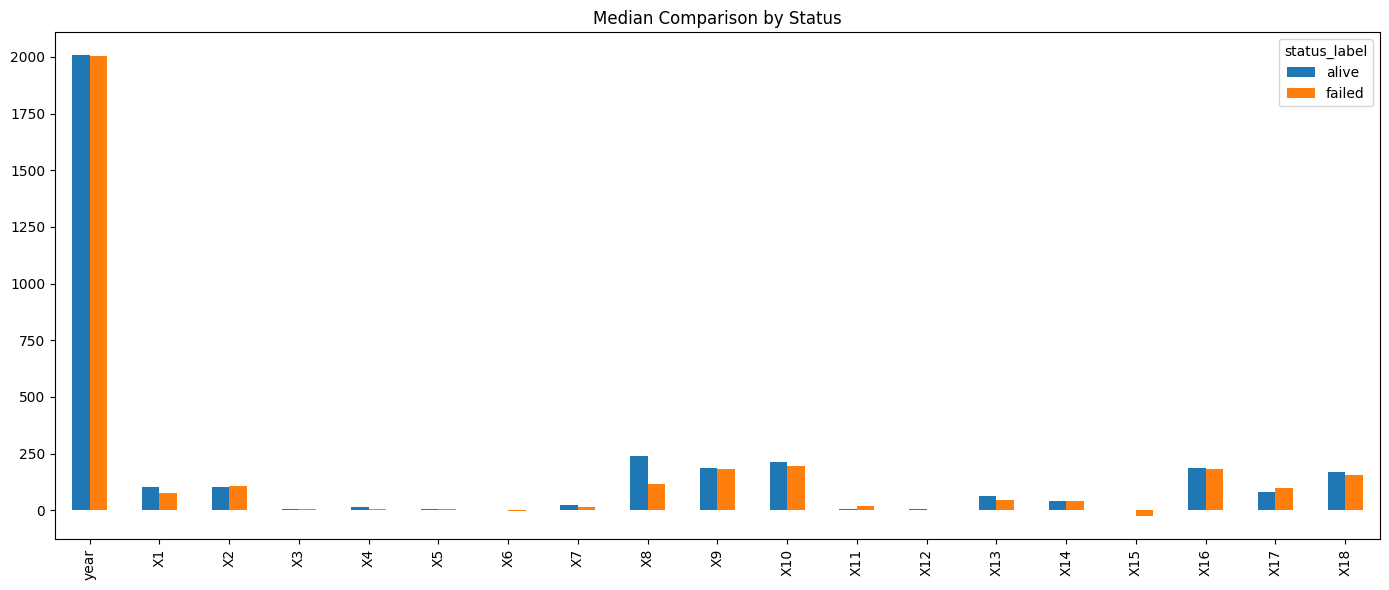

In [5]:
med=df.groupby('status_label')[list(num)].median().T
display(med)
med.plot(kind='bar',figsize=(14,6))
plt.title('Median Comparison by Status')
plt.tight_layout()
plt.show()

## Boxplots by Bankruptcy Status

<Figure size 600x400 with 0 Axes>

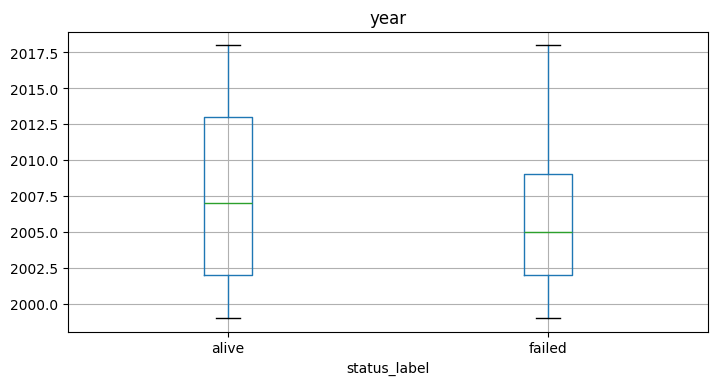

<Figure size 600x400 with 0 Axes>

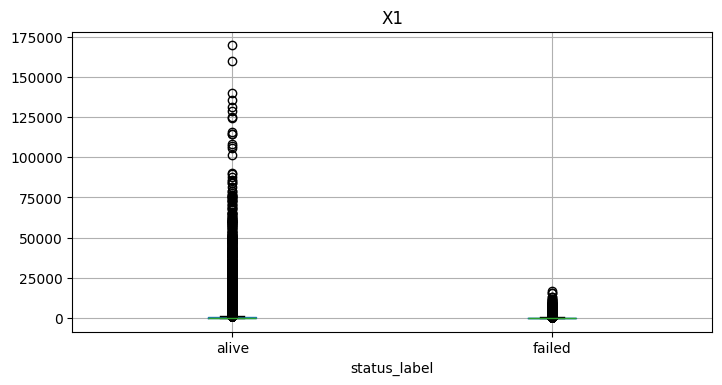

<Figure size 600x400 with 0 Axes>

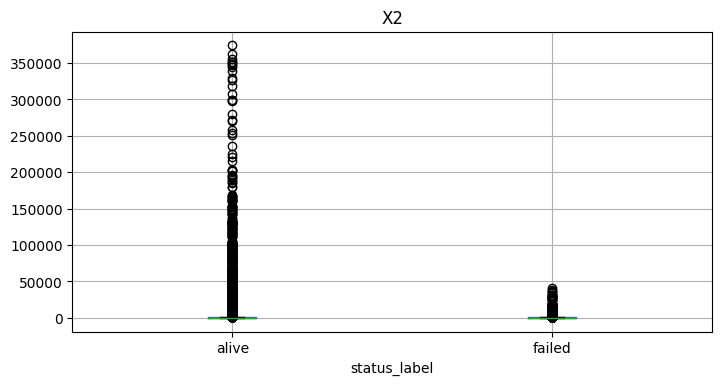

<Figure size 600x400 with 0 Axes>

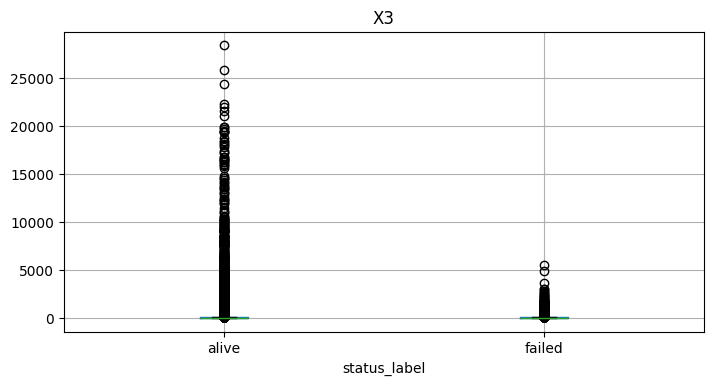

<Figure size 600x400 with 0 Axes>

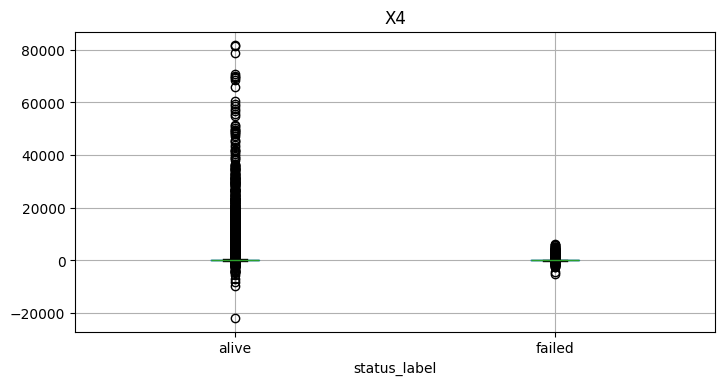

<Figure size 600x400 with 0 Axes>

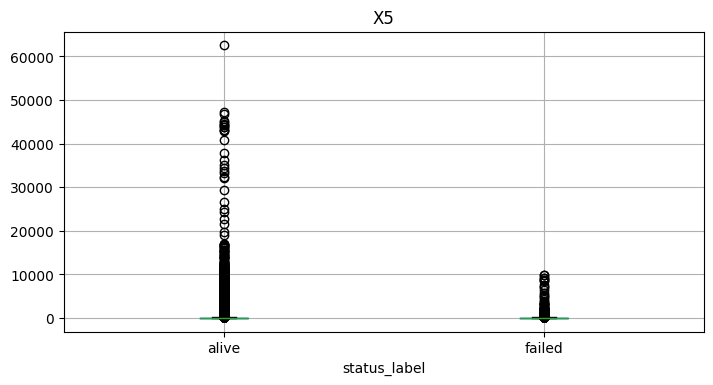

<Figure size 600x400 with 0 Axes>

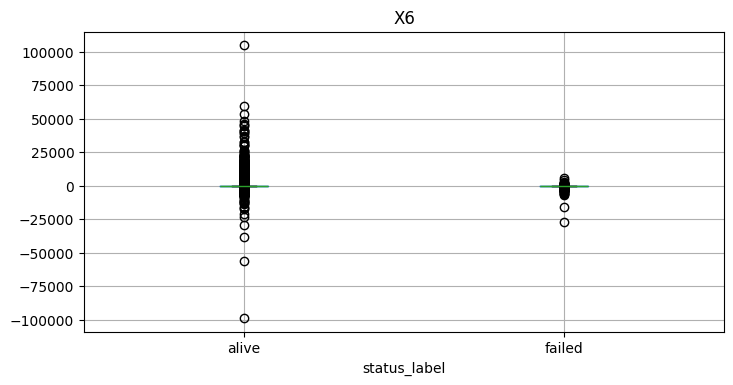

<Figure size 600x400 with 0 Axes>

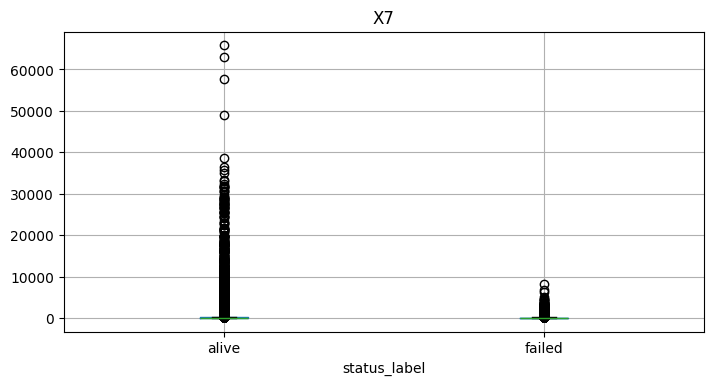

<Figure size 600x400 with 0 Axes>

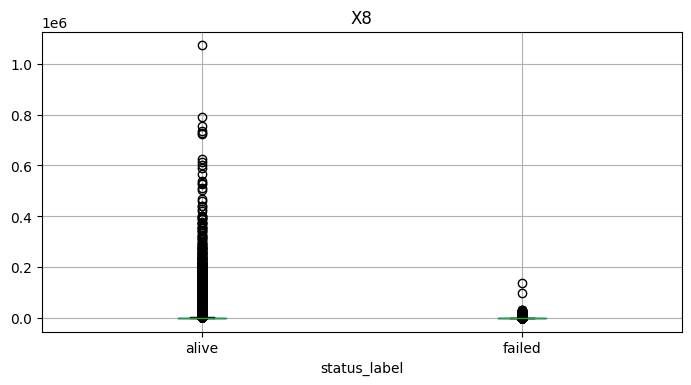

<Figure size 600x400 with 0 Axes>

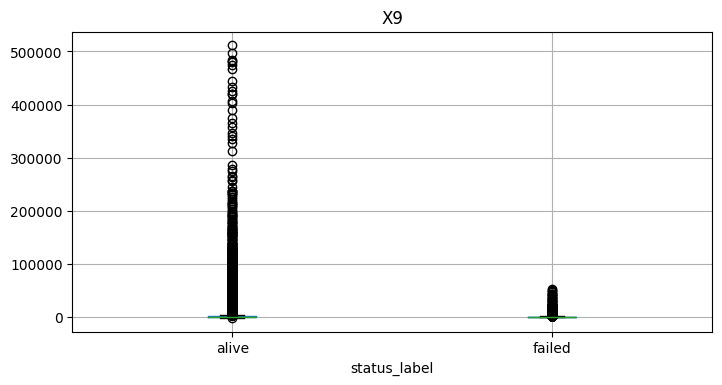

<Figure size 600x400 with 0 Axes>

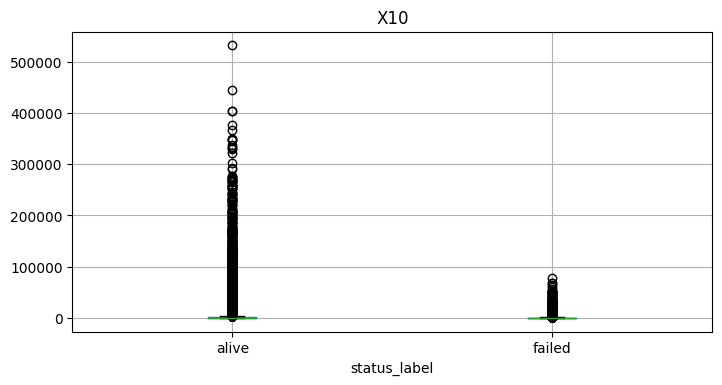

<Figure size 600x400 with 0 Axes>

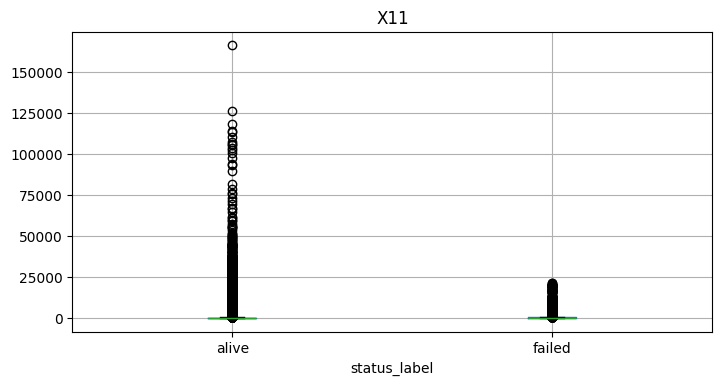

<Figure size 600x400 with 0 Axes>

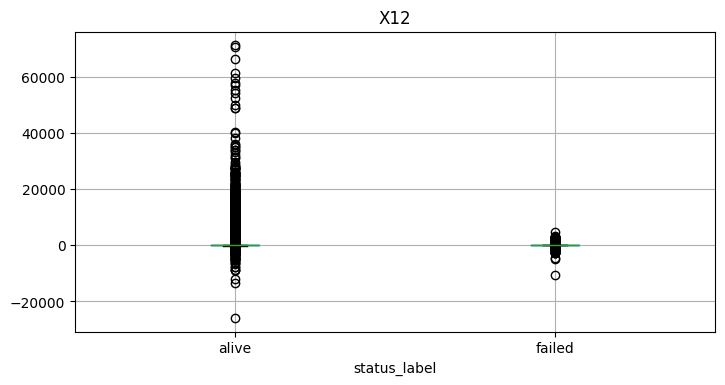

<Figure size 600x400 with 0 Axes>

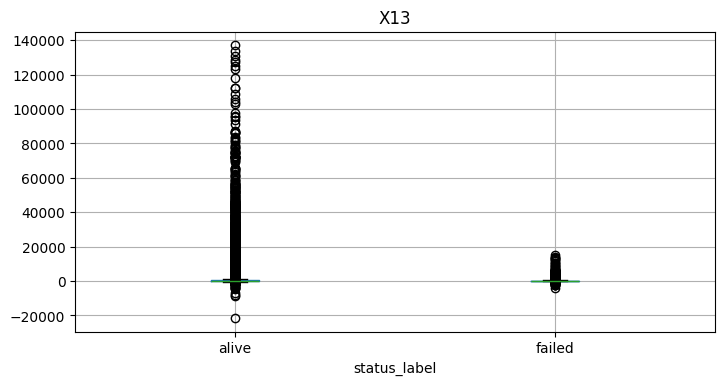

<Figure size 600x400 with 0 Axes>

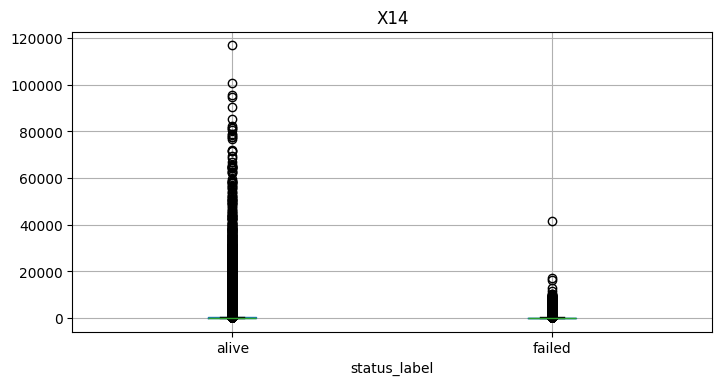

<Figure size 600x400 with 0 Axes>

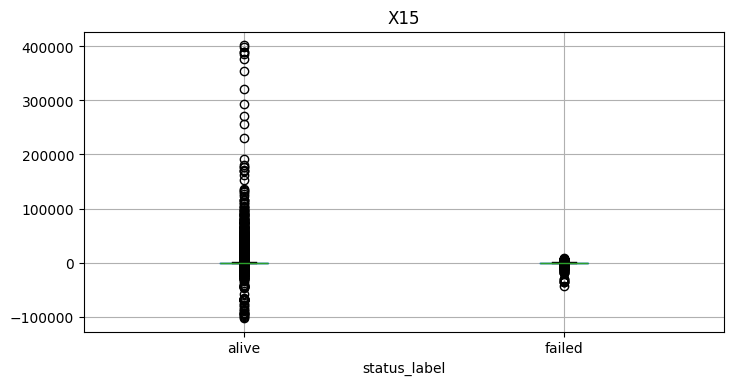

<Figure size 600x400 with 0 Axes>

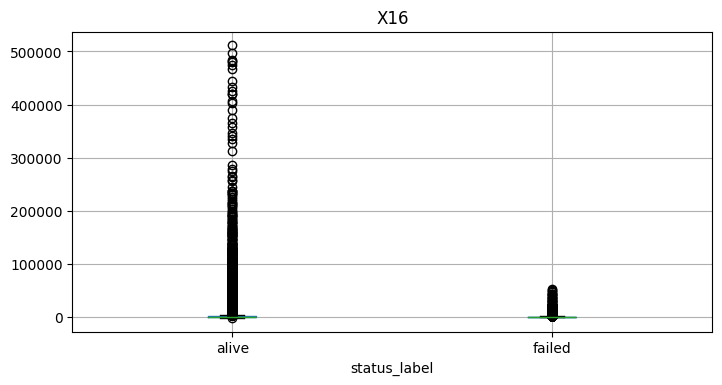

<Figure size 600x400 with 0 Axes>

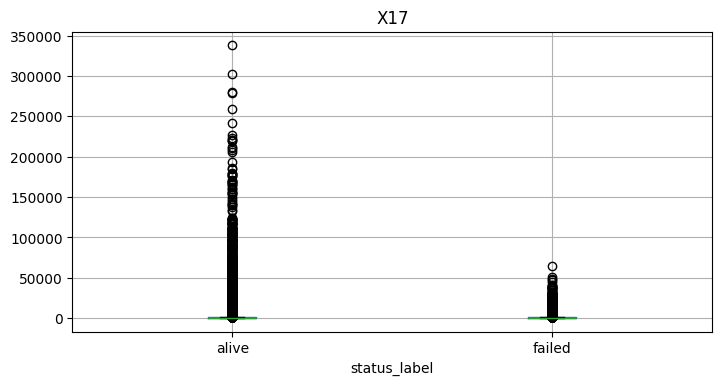

<Figure size 600x400 with 0 Axes>

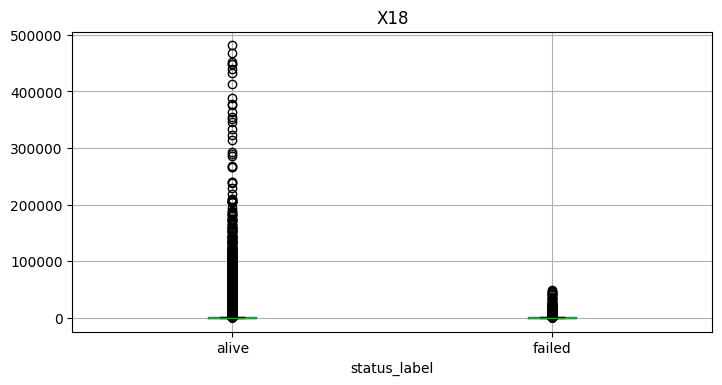

In [6]:
for col in num:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col,by='status_label')
    plt.title(col)
    plt.suptitle('')
    plt.show()

## Distribution Comparison

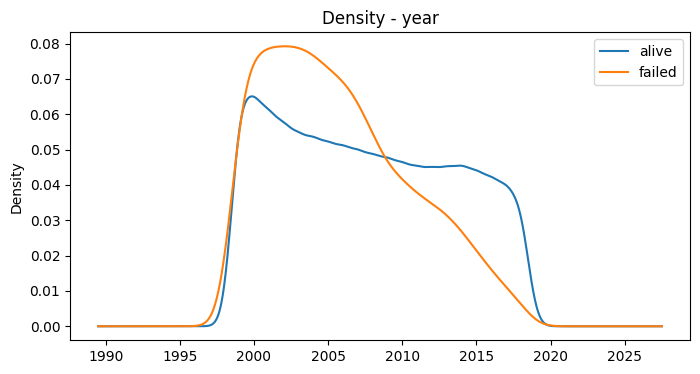

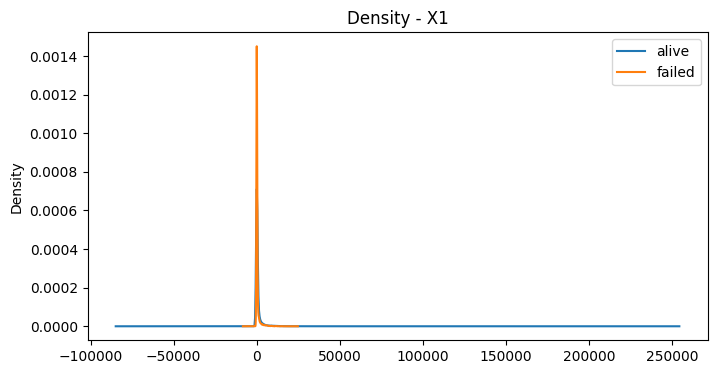

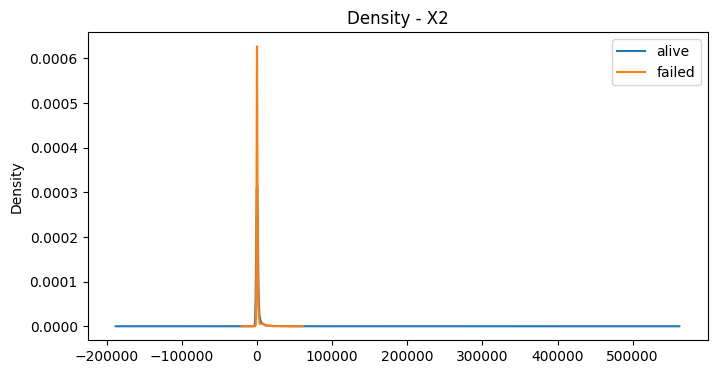

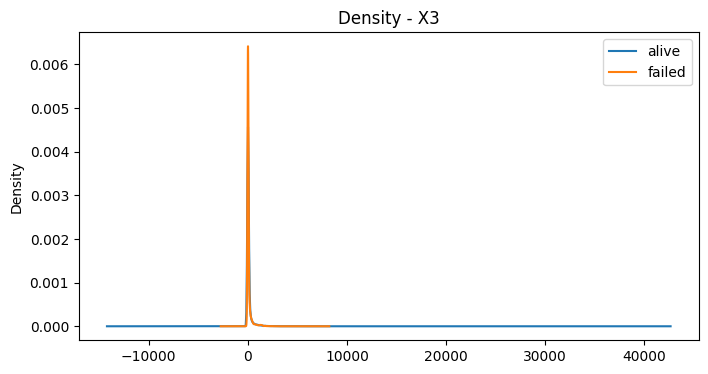

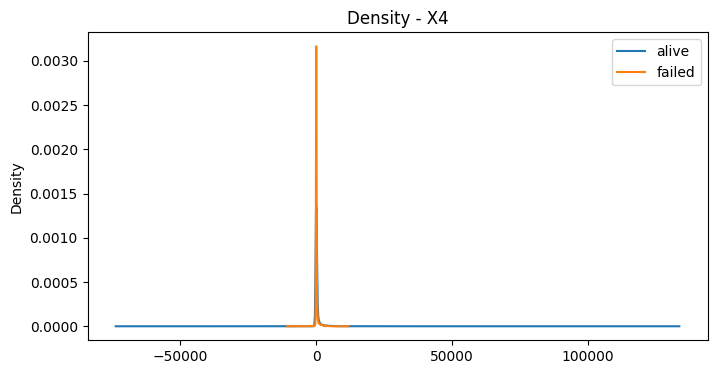

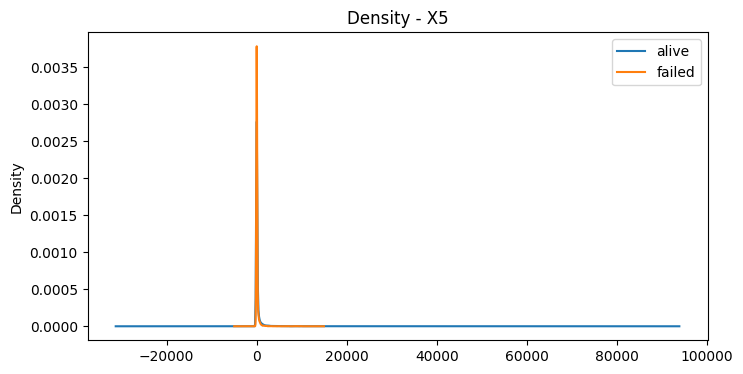

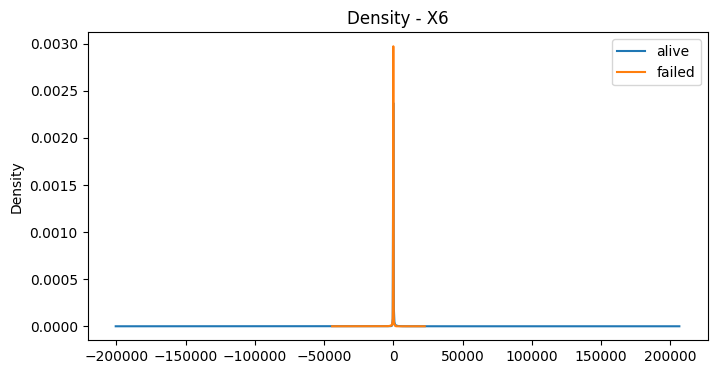

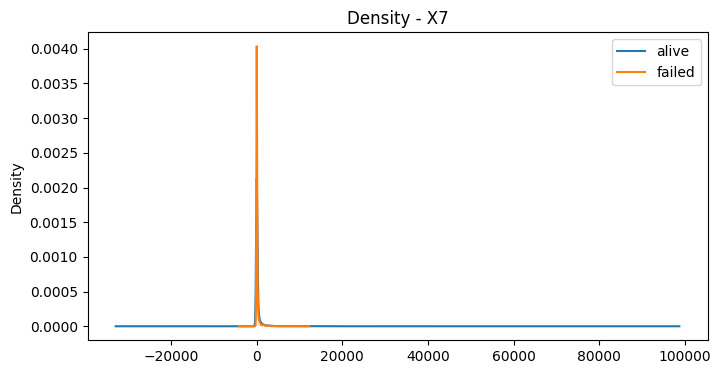

In [7]:
for col in num[:8]:
    plt.figure(figsize=(8,4))
    for status in df['status_label'].unique():
        df[df['status_label']==status][col].plot(kind='density',label=status)
    plt.title(f'Density - {col}')
    plt.legend()
    plt.show()

## Difference Table

In [8]:
alive=df[df['status_label']=='alive'][list(num)].mean()
other=df[df['status_label']!='alive'][list(num)].mean()
diff=(alive-other).to_frame('Mean Difference').sort_values('Mean Difference',key=abs,ascending=False)
display(diff)

,Mean Difference
X8,2738.202146
X10,1287.924410
X9,1263.914409
X16,1263.914409
X18,1008.798426
X2,790.641566
X15,747.141977
X17,542.755226
X1,515.203262
X13,473.272956


## Business Interpretation

In [9]:
print('1. Compare features with the largest differences between classes.')
print('2. Features with clear separation may be useful predictors.')
print('3. Overlapping distributions may require nonlinear models.')
print('4. Validate findings with statistical tests in later analysis.')

1. Compare features with the largest differences between classes.
2. Features with clear separation may be useful predictors.
3. Overlapping distributions may require nonlinear models.
4. Validate findings with statistical tests in later analysis.
